# Chapter 2 · A label roster — 10 artists, 40 releases, 2026

**Scenario.** You've been hired by a mid-size **European independent label**. This
year they plan to put out **40 single releases** from a roster of **10 artists**,
released **globally**. Each single drops on a **Friday** ("New Music Friday"),
spread across the year.

This notebook simulates the **daily streams** for every release and reports
**descriptive analytics only** — release calendar, time series, seasonality, and
how concentrated the streams are across artists and tracks.

> *Next iteration* will add **ad spend** per release and estimate its impact. To
> make that clean, every release here carries a latent `peak` (expected day-0
> streams) that ad spend will later scale — nothing else needs to change.

---

### Roster & tiers (proposed, realistic for a mid-size indie)

| Tier | Artists | Typical single peak (streams/day) |
|---|---|---|
| Flagship | 1 | ~30–45k |
| Mid-tier | 3 | ~7–13k |
| Emerging | 4 | ~1–3k |
| Developing | 2 | ~0.2–0.5k |

### The DGP (same engine as the sandbox)
For release *i*, weekday *w*, *a* days after release:
$$\mu_{i,a}=\beta_i\cdot e^{-\ln 2\,a/h_i}\cdot s_w\cdot(1+v_{i,a}),\qquad
y_{i,a}\sim\text{NegBinomial}(\mu_{i,a},r).$$
Peak $\beta_i$ = artist tier level × release-specific quality; $h_i$ = decay
half-life; $s_w$ = Friday/weekend lift; $v_{i,a}$ = rare viral bump.

The carryover/saturation/viral/concentration primitives now live in the shared
`mml` module — this chapter imports `nb_draw`, `viral_bump`, and `gini` from there
rather than re-defining them inline.

## 1 · Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
from mml import nb_draw, viral_bump, gini

import matplotlib.dates as mdates
from matplotlib.lines import Line2D

plt.rcParams.update({
    "figure.figsize": (11, 4.5), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})
SEED = 2026
rng = np.random.default_rng(SEED)

YEAR_START, YEAR_END = "2026-01-01", "2026-12-31"
dates = pd.date_range(YEAR_START, YEAR_END, freq="D")
n_days = len(dates)

# day-of-week multipliers Mon..Sun (Fri/weekend lift), normalised to mean 1
dow_mult = np.array([0.95, 0.93, 0.95, 1.00, 1.18, 1.14, 1.06])
dow_mult /= dow_mult.mean()

# global DGP knobs
HALFLIFE_MED, HALFLIFE_SIGMA = 28.0, 0.35      # decay half-life (days)
HALFLIFE_QUAL_BETA = 0.15
QUAL_SIGMA = 0.45                              # within-artist release variation
VIRAL_P, VIRAL_NLAM = 0.30, 1.1               # P(release goes viral), # shocks
VIRAL_LO, VIRAL_HI, VIRAL_TAU = 3.0, 16.0, 9.0
NB_R = 6.0                                     # NegBinomial over-dispersion
print(f"Campaign window: {dates[0].date()} -> {dates[-1].date()}  ({n_days} days)")

Campaign window: 2026-01-01 -> 2026-12-31  (365 days)


## 2 · Roster & release calendar

Ten named artists across four tiers; 40 singles assigned to Fridays spread Jan–early Dec so each release has runway before year-end.

In [2]:
roster = pd.DataFrame([
    ("Aurora Vance",   "synth-pop",  "Flagship",   38000, 4),
    ("Måns Eklund",    "indie-pop",  "Mid",        12000, 5),
    ("Lena Brandt",    "electropop", "Mid",         9000, 4),
    ("Théo Mercier",   "house",      "Mid",         7000, 4),
    ("Niamh O'Connor", "folk-pop",   "Emerging",    2500, 4),
    ("Dario Conti",    "indie-rock", "Emerging",    2000, 4),
    ("Sofia Almeida",  "R&B",        "Emerging",    1500, 4),
    ("Kai Lindqvist",  "hyperpop",   "Emerging",    1200, 4),
    ("Émile Rousseau", "bedroom-pop","Developing",   400, 4),
    ("Petra Novak",    "alt-pop",    "Developing",   250, 3),
], columns=["artist", "genre", "tier", "tier_peak", "n_releases"])
TOTAL_RELEASES = int(roster.n_releases.sum())

# candidate release Fridays: Jan 2 -> Dec 4, 2026
fridays = pd.date_range(YEAR_START, "2026-12-04", freq="W-FRI")
chosen = np.sort(rng.choice(fridays, size=TOTAL_RELEASES, replace=False))

rows, k = [], 0
order = roster.loc[roster.index.repeat(roster.n_releases)].reset_index(drop=True)
order = order.sample(frac=1, random_state=SEED).reset_index(drop=True)  # interleave artists across the year
for _, art in order.iterrows():
    quality = rng.lognormal(0.0, QUAL_SIGMA)
    peak = art.tier_peak * quality
    hl = HALFLIFE_MED * np.exp(HALFLIFE_QUAL_BETA*np.log(quality)) * np.exp(rng.normal(0, HALFLIFE_SIGMA))
    rows.append(dict(track_id=f"S{k+1:02d}", artist=art.artist, genre=art.genre,
                     tier=art.tier, quality=quality, peak=peak, half_life=hl))
    k += 1
releases = pd.DataFrame(rows)
releases["release_date"] = chosen
releases["title"] = [f"{a.split()[0]} — single {i}"
                     for i, a in enumerate(releases.artist, 1)]
releases = releases.sort_values("release_date").reset_index(drop=True)
print(f"{len(roster)} artists, {TOTAL_RELEASES} releases on "
      f"{releases.release_date.dt.date.nunique()} distinct Fridays")
releases[["track_id","release_date","artist","tier","genre","peak","half_life"]].head(8)

10 artists, 40 releases on 40 distinct Fridays


,track_id,release_date,artist,tier,genre,peak,half_life
0,S01,2026-01-02,Émile Rousseau,Developing,bedroom-pop,502.404832,39.379569
1,S02,2026-01-09,Dario Conti,Emerging,indie-rock,2192.705737,22.787392
2,S03,2026-01-16,Måns Eklund,Mid,indie-pop,8275.416194,43.902570
3,S04,2026-01-30,Niamh O'Connor,Emerging,folk-pop,3266.001297,37.494739
4,S05,2026-02-06,Théo Mercier,Mid,house,18699.182630,24.386701
5,S06,2026-02-13,Kai Lindqvist,Emerging,hyperpop,3796.492317,100.261900
6,S07,2026-02-20,Kai Lindqvist,Emerging,hyperpop,2485.832121,41.718083
7,S08,2026-02-27,Sofia Almeida,Emerging,R&B,1112.650747,37.919538


### Release calendar

Each dot is a single; height = artist, size = expected peak, colour = genre.

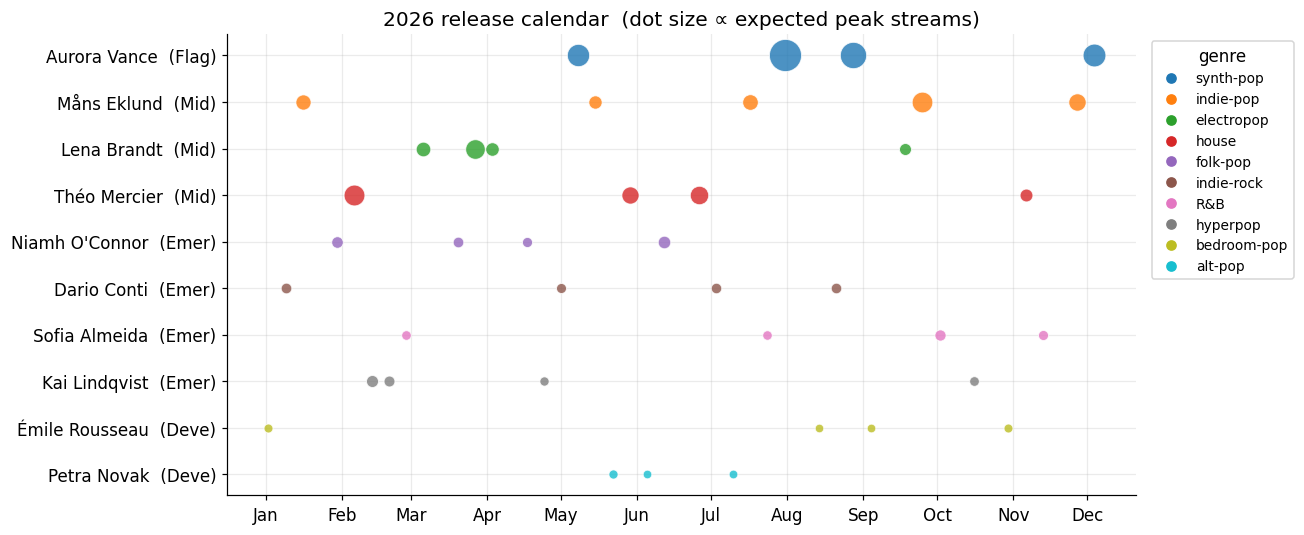

In [3]:
genres = roster.genre.unique()
cmap = plt.get_cmap("tab10")
gcol = {g: cmap(i) for i, g in enumerate(genres)}
artist_order = roster.sort_values("tier_peak").artist.tolist()
ypos = {a: i for i, a in enumerate(artist_order)}

fig, ax = plt.subplots(figsize=(12, 5))
for _, r in releases.iterrows():
    ax.scatter(r.release_date, ypos[r.artist], s=30+r.peak/120,
               color=gcol[r.genre], alpha=0.8, edgecolor="white", lw=0.6, zorder=3)
ax.set_yticks(range(len(artist_order)))
ax.set_yticklabels([f"{a}  ({roster.set_index('artist').loc[a,'tier'][:4]})"
                    for a in artist_order])
ax.set_title("2026 release calendar  (dot size ∝ expected peak streams)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(handles=[Line2D([0],[0],marker='o',ls='',color=gcol[g],label=g) for g in genres],
          loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, title="genre")
plt.tight_layout(); plt.show()

## 3 · Simulate daily streams

`viral_bump` and `nb_draw` come from `mml`; the module-level `VIRAL_*` knobs are
passed through as keyword arguments so the DGP is identical to the sandbox.

In [4]:
panel = []
for _, tr in releases.iterrows():
    obs = dates[dates >= tr.release_date]
    a = np.arange(len(obs)); wd = obs.weekday.to_numpy()
    lam = np.log(2)/tr.half_life
    g = np.random.default_rng(abs(hash(tr.track_id)) % (2**32))
    bump = viral_bump(len(a), g, p_track=VIRAL_P, n_lambda=VIRAL_NLAM,
                      mag_lo=VIRAL_LO, mag_hi=VIRAL_HI, tau=VIRAL_TAU)
    mu = tr.peak * np.exp(-lam*a) * dow_mult[wd] * (1 + bump)
    panel.append(pd.DataFrame(dict(date=obs, track_id=tr.track_id, artist=tr.artist,
        tier=tr.tier, genre=tr.genre, days_since_release=a,
        streams=nb_draw(mu, NB_R, g))))
panel = pd.concat(panel, ignore_index=True).sort_values(["date","track_id"]).reset_index(drop=True)
print(f"Panel: {len(panel):,} track-day rows | total streams: {panel.streams.sum():,.0f}")
panel.head()

Panel: 8,050 track-day rows | total streams: 11,731,483


,date,track_id,artist,tier,genre,days_since_release,streams
0,2026-01-02,S01,Émile Rousseau,Developing,bedroom-pop,0,693
1,2026-01-03,S01,Émile Rousseau,Developing,bedroom-pop,1,642
2,2026-01-04,S01,Émile Rousseau,Developing,bedroom-pop,2,317
3,2026-01-05,S01,Émile Rousseau,Developing,bedroom-pop,3,462
4,2026-01-06,S01,Émile Rousseau,Developing,bedroom-pop,4,249


## 4 · Campaign KPIs

In [5]:
tot = panel.streams.sum()
per_rel = panel.groupby("track_id").streams.sum()
kpi = pd.Series({
    "Artists": len(roster),
    "Releases": TOTAL_RELEASES,
    "Total streams (year)": tot,
    "Avg streams / release": per_rel.mean(),
    "Median streams / release": per_rel.median(),
    "Biggest release (streams)": per_rel.max(),
    "Smallest release (streams)": per_rel.min(),
    "Best single day (one track)": panel.streams.max(),
    "Avg release cadence (days)": np.diff(np.sort(releases.release_date)).astype('timedelta64[D]').mean().astype(int),
})
kpi.to_frame("value").round(0)

,value
Artists,10.0
Releases,40.0
Total streams (year),11731483.0
Avg streams / release,293287.0
Median streams / release,156689.0
Biggest release (streams),1325579.0
Smallest release (streams),4401.0
Best single day (one track),74296.0
Avg release cadence (days),8.0


## 5 · Total daily streams across the year

Catalog of new releases builds up over the year; the weekly ripple is the Friday/weekend cycle.

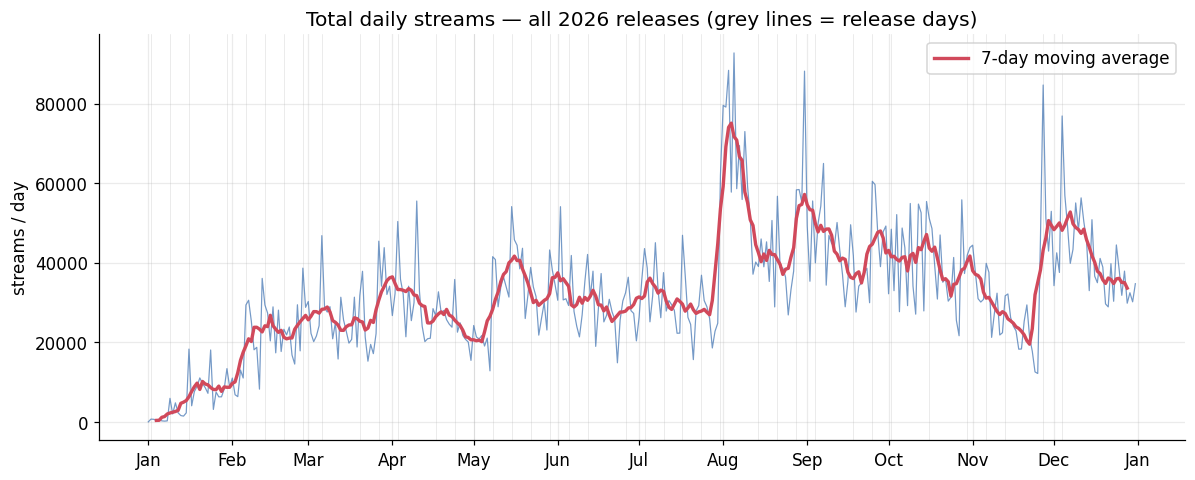

In [6]:
daily = panel.groupby("date").streams.sum().reindex(dates, fill_value=0)
fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, lw=0.8, color="#3b6fb0", alpha=0.7)
ax.plot(daily.index, daily.rolling(7, center=True).mean(), lw=2.2, color="#d1495b",
        label="7-day moving average")
# mark release days
for d in releases.release_date:
    ax.axvline(d, color="grey", lw=0.4, alpha=0.25, zorder=0)
ax.set_title("Total daily streams — all 2026 releases (grey lines = release days)")
ax.set_ylabel("streams / day"); ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout(); plt.show()

### Cumulative streams (campaign-to-date)

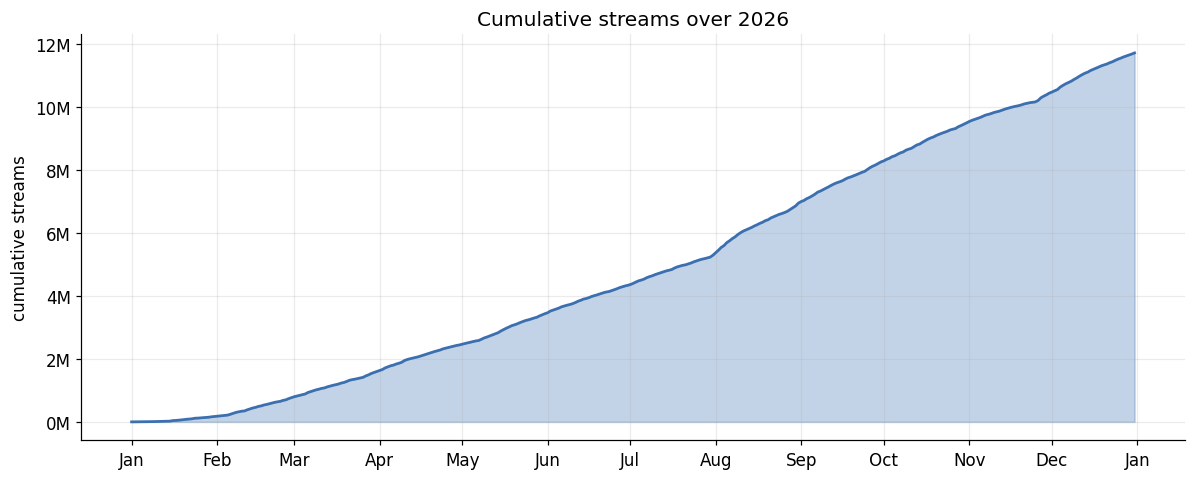

In [7]:
fig, ax = plt.subplots()
ax.fill_between(daily.index, daily.cumsum().values, color="#3b6fb0", alpha=0.3)
ax.plot(daily.index, daily.cumsum().values, color="#3b6fb0", lw=1.8)
ax.set_title("Cumulative streams over 2026"); ax.set_ylabel("cumulative streams")
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v/1e6:.0f}M"))
plt.tight_layout(); plt.show()

## 6 · Who drives the streams?

Stacked daily streams by artist, and total streams per artist.

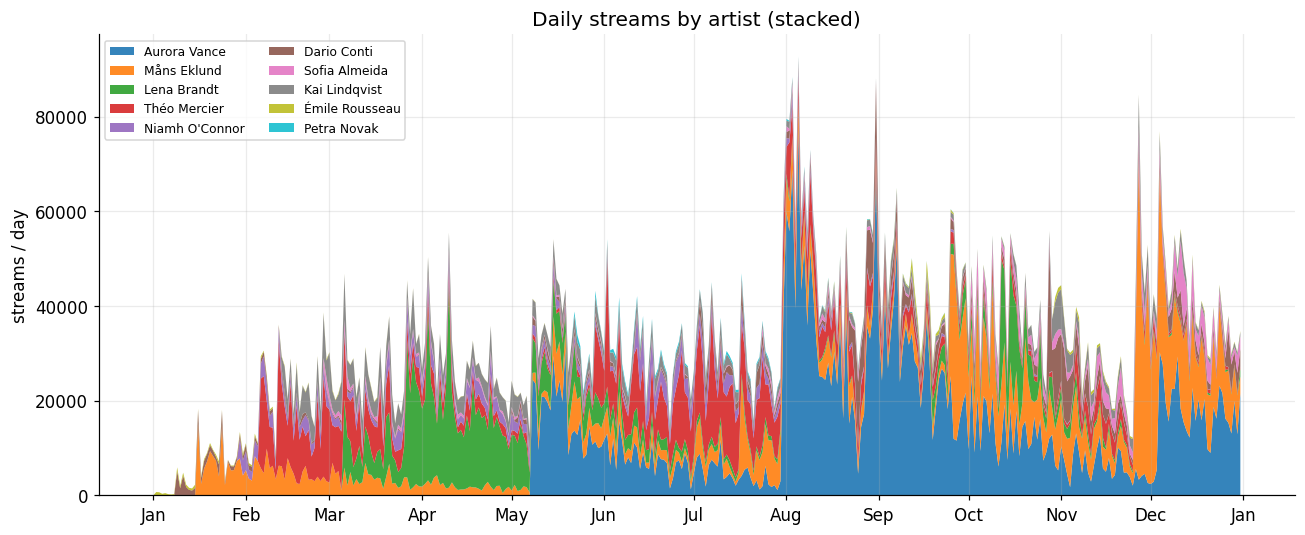

In [8]:
piv = (panel.pivot_table(index="date", columns="artist", values="streams",
        aggfunc="sum").reindex(dates).fillna(0))
piv = piv[roster.sort_values("tier_peak", ascending=False).artist]   # big -> small
fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(piv.index, piv.T.values, labels=piv.columns,
             colors=[plt.get_cmap("tab10")(i % 10) for i in range(piv.shape[1])], alpha=0.9)
ax.set_title("Daily streams by artist (stacked)"); ax.set_ylabel("streams / day")
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

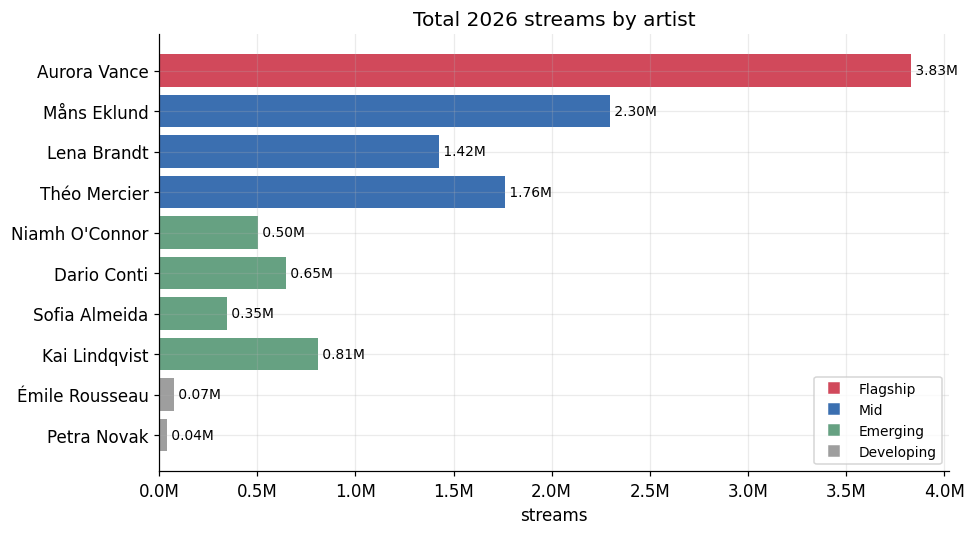

In [9]:
by_artist = (panel.groupby("artist").streams.sum()
             .reindex(roster.sort_values("tier_peak").artist))
fig, ax = plt.subplots(figsize=(9, 5))
colors = [{"Flagship":"#d1495b","Mid":"#3b6fb0","Emerging":"#66a182","Developing":"#9e9e9e"}[t]
          for t in roster.set_index("artist").loc[by_artist.index,"tier"]]
ax.barh(by_artist.index, by_artist.values, color=colors)
ax.set_title("Total 2026 streams by artist"); ax.set_xlabel("streams")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v/1e6:.1f}M"))
for i,v in enumerate(by_artist.values): ax.text(v, i, f" {v/1e6:.2f}M", va="center", fontsize=9)
ax.legend(handles=[Line2D([0],[0],marker='s',ls='',color=c,label=t) for t,c in
          {"Flagship":"#d1495b","Mid":"#3b6fb0","Emerging":"#66a182","Developing":"#9e9e9e"}.items()],
          loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

## 7 · Release shape: spike & decay (event time)

Every release overlaid by days-since-release (log scale), plus the average curve with its fitted half-life.

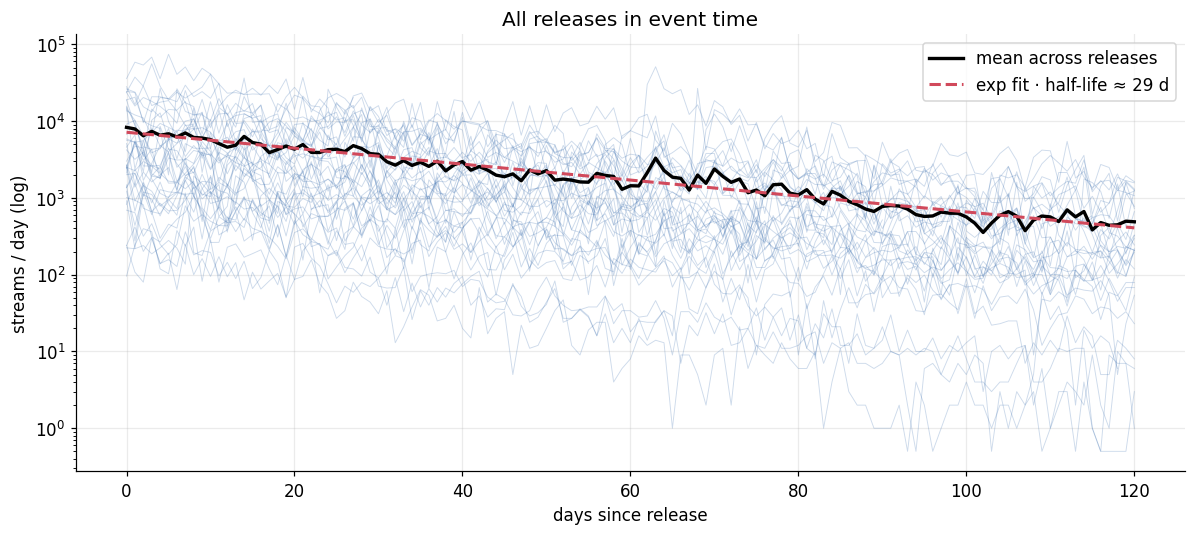

Implied catalog half-life ≈ 29.0 days


In [10]:
H = 120
fig, ax = plt.subplots(figsize=(11, 5))
for tid, d in panel[panel.days_since_release <= H].groupby("track_id"):
    ax.plot(d.days_since_release, d.streams.clip(lower=0.5), lw=0.6, color="#3b6fb0", alpha=0.25)
ev = panel[panel.days_since_release <= H].groupby("days_since_release").streams.mean()
sl, ic = np.polyfit(ev.index, np.log(ev.values), 1)
hl = np.log(2)/(-sl)
ax.plot(ev.index, ev.values, color="black", lw=2.2, label="mean across releases")
ax.plot(ev.index, np.exp(ic+sl*ev.index), color="#d1495b", lw=2, ls="--",
        label=f"exp fit · half-life ≈ {hl:.0f} d")
ax.set_yscale("log"); ax.set_xlabel("days since release"); ax.set_ylabel("streams / day (log)")
ax.set_title("All releases in event time"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Implied catalog half-life ≈ {hl:.1f} days")

## 8 · Day-of-week seasonality

Residualised against each release's own mean. Friday/weekend lift is the injected signal.

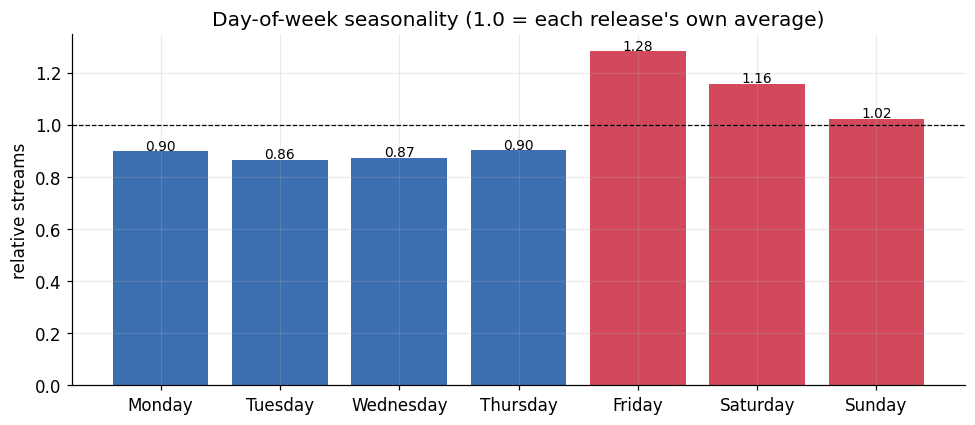

Fri/weekend lift vs Mon–Thu: 30.5%


In [11]:
t = panel.copy()
t["weekday"] = pd.Categorical(t.date.dt.day_name(),
    categories=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"], ordered=True)
t["rel"] = t.streams / t.groupby("track_id").streams.transform("mean")
dow = t.groupby("weekday", observed=True).rel.mean()
fig, ax = plt.subplots(figsize=(9,4))
bars = ax.bar(dow.index.astype(str), dow.values, color=["#3b6fb0"]*4+["#d1495b"]*3)
ax.axhline(1, color="k", lw=0.8, ls="--"); ax.set_ylabel("relative streams")
ax.set_title("Day-of-week seasonality (1.0 = each release's own average)")
for b,v in zip(bars,dow.values): ax.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
lift = dow[['Friday','Saturday','Sunday']].mean()/dow[['Monday','Tuesday','Wednesday','Thursday']].mean()-1
print(f"Fri/weekend lift vs Mon–Thu: {lift:.1%}")

## 9 · Distribution & concentration

Heavy-tailed daily streams, and how lopsided lifetime streams are across the 40 releases (Lorenz + Gini, via `mml.gini`).

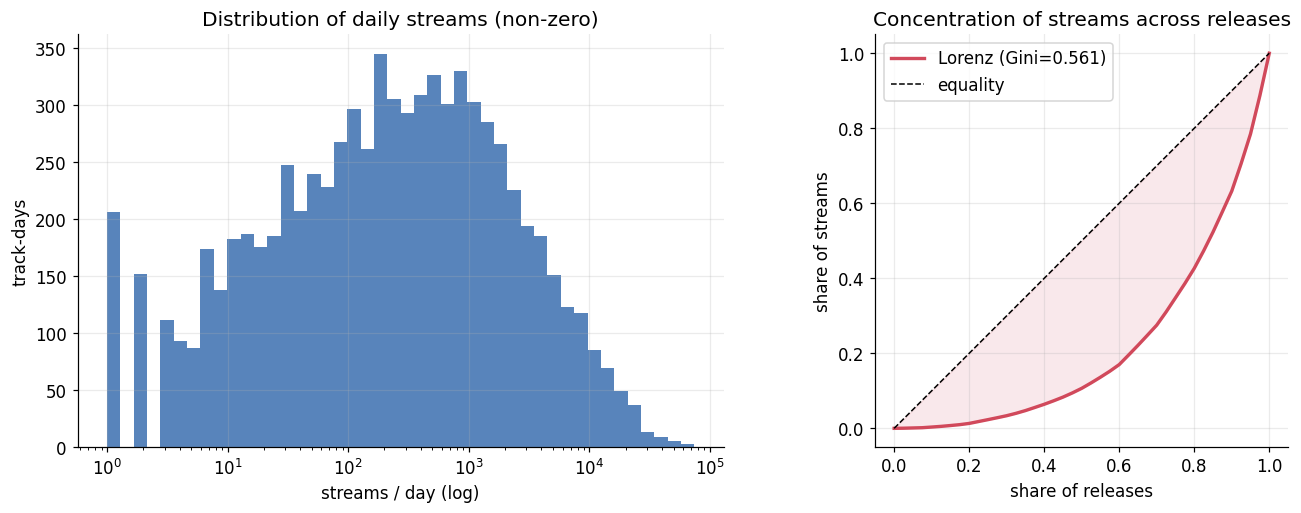

Gini across releases: 0.561


,share of all streams
Top 10% of releases,0.368
Top 20% of releases,0.574
Top 50% of releases,0.893


In [12]:
nz = panel.streams[panel.streams>0]
tot_sorted = np.sort(per_rel.values); g = gini(tot_sorted)
cum = np.insert(np.cumsum(tot_sorted)/tot_sorted.sum(),0,0); frac=np.linspace(0,1,len(cum))

fig, (a1,a2) = plt.subplots(1,2, figsize=(13,4.8))
a1.hist(nz, bins=np.logspace(0,np.log10(nz.max()),45), color="#3b6fb0", alpha=0.85)
a1.set_xscale("log"); a1.set_title("Distribution of daily streams (non-zero)")
a1.set_xlabel("streams / day (log)"); a1.set_ylabel("track-days")
a2.plot(frac,cum,color="#d1495b",lw=2.2,label=f"Lorenz (Gini={g:.3f})")
a2.plot([0,1],[0,1],"k--",lw=1,label="equality"); a2.fill_between(frac,cum,frac,color="#d1495b",alpha=0.12)
a2.set_title("Concentration of streams across releases"); a2.set_aspect("equal")
a2.set_xlabel("share of releases"); a2.set_ylabel("share of streams"); a2.legend(loc="upper left")
plt.tight_layout(); plt.show()

shares = pd.Series({"Top 10% of releases": tot_sorted[int(.9*len(tot_sorted)):].sum()/tot_sorted.sum(),
                    "Top 20% of releases": tot_sorted[int(.8*len(tot_sorted)):].sum()/tot_sorted.sum(),
                    "Top 50% of releases": tot_sorted[int(.5*len(tot_sorted)):].sum()/tot_sorted.sum()})
print(f"Gini across releases: {g:.3f}")
shares.to_frame("share of all streams").round(3)

## 10 · Per-release & per-artist tables

In [13]:
rel_tbl = (panel.groupby("track_id").agg(total=("streams","sum"), peak_day=("streams","max"),
            days=("streams","size")).reset_index()
           .merge(releases[["track_id","artist","tier","genre","release_date"]], on="track_id")
           .sort_values("total", ascending=False))
rel_tbl["release_date"] = rel_tbl.release_date.dt.date
print("Top 10 releases")
rel_tbl.head(10)[["track_id","artist","tier","genre","release_date","total","peak_day","days"]].round(0)

Top 10 releases


,track_id,artist,tier,genre,release_date,total,peak_day,days
29,S30,Aurora Vance,Flagship,synth-pop,2026-08-28,1325579,55916,126
26,S27,Aurora Vance,Flagship,synth-pop,2026-07-31,1198984,74296,154
32,S33,Måns Eklund,Mid,indie-pop,2026-09-25,926481,51163,98
15,S16,Aurora Vance,Flagship,synth-pop,2026-05-08,860846,31201,238
4,S05,Théo Mercier,Mid,house,2026-02-06,645124,26466,329
10,S11,Lena Brandt,Mid,electropop,2026-03-27,637199,36471,280
18,S19,Théo Mercier,Mid,house,2026-05-29,587287,26755,217
2,S03,Måns Eklund,Mid,indie-pop,2026-01-16,547133,15132,350
5,S06,Kai Lindqvist,Emerging,hyperpop,2026-02-13,473773,7086,322
39,S40,Aurora Vance,Flagship,synth-pop,2026-12-04,446219,26286,28


In [14]:
art_tbl = (panel.groupby("artist").agg(streams=("streams","sum")).join(
    releases.groupby("artist").agg(releases=("track_id","size"))))
art_tbl["avg_per_release"] = art_tbl.streams/art_tbl.releases
art_tbl = art_tbl.merge(roster[["artist","tier"]], on="artist").sort_values("streams", ascending=False)
print("By artist")
art_tbl[["artist","tier","releases","streams","avg_per_release"]].round(0).reset_index(drop=True)

By artist


,artist,tier,releases,streams,avg_per_release
0,Aurora Vance,Flagship,4,3831628,957907.0
1,Måns Eklund,Mid,5,2297238,459448.0
2,Théo Mercier,Mid,4,1760216,440054.0
3,Lena Brandt,Mid,4,1423653,355913.0
4,Kai Lindqvist,Emerging,4,808047,202012.0
5,Dario Conti,Emerging,4,647562,161890.0
6,Niamh O'Connor,Emerging,4,501494,125374.0
7,Sofia Almeida,Emerging,4,345804,86451.0
8,Émile Rousseau,Developing,4,74094,18524.0
9,Petra Novak,Developing,3,41747,13916.0


## 11 · Takeaways

- **Scale.** 40 singles from 10 artists generate the year's total shown in the KPI
  table — concentrated heavily in the flagship and mid-tier acts.
- **Release-and-decay** dominates every track; the catalog total rises through the
  year as releases stack, with a persistent Friday/weekend cycle on top.
- **Hits carry the campaign.** A high Gini / steep Lorenz curve: the top releases
  account for most of the streams — exactly what to expect, and what makes
  **per-release ad allocation** (next iteration) worth optimising.

### Ready for ad spend (next iteration)
Each release has a latent `peak` (β). The natural next step:
`peak_effective = peak × f(ad_spend)` with diminishing returns (e.g. β·(1+κ·log(1+spend/s₀))),
then compare streams-with vs streams-without to estimate ROI / cost-per-stream.
The tidy `panel` (track-day) and `releases` (one row per single) tables are the inputs.